In [1]:
from google.colab import files
import pickle

# Upload QR codes
uploaded_qr = files.upload()
qr_filename = list(uploaded_qr.keys())[0]

# Upload labels
uploaded_labels = files.upload()
labels_filename = list(uploaded_labels.keys())[0]

# Load QR codes
with open(qr_filename, 'rb') as f:
    qr_codes = pickle.load(f)

# Load labels
with open(labels_filename, 'rb') as f:
    qr_labels = pickle.load(f)

# Check
print("QR codes:")
print(type(qr_codes), qr_codes.shape)

print("\nLabels:")
print(type(qr_labels), qr_labels.shape)

Saving qr_codes_29.pickle to qr_codes_29.pickle


Saving qr_codes_29_labels.pickle to qr_codes_29_labels.pickle
QR codes:
<class 'numpy.ndarray'> (9987, 69, 69)

Labels:
<class 'numpy.ndarray'> (9987,)


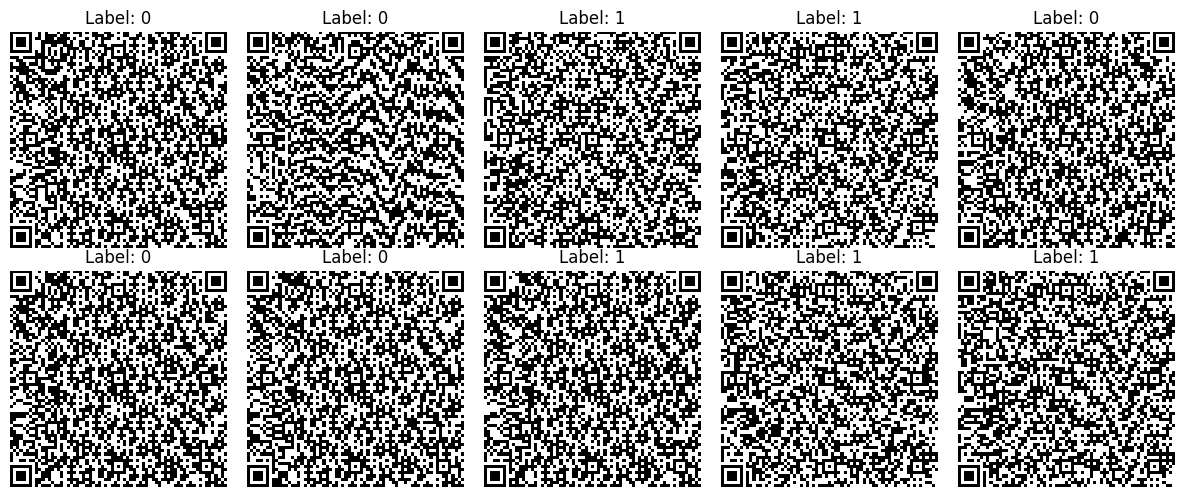

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Select 10 random samples
indices = np.random.choice(len(qr_codes), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(qr_codes[indices[i]], cmap="gray")
    ax.set_title(f"Label: {qr_labels[indices[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("QR codes shape:", qr_codes.shape)
print("Labels shape:", qr_labels.shape)

print("QR codes dtype:", qr_codes.dtype)
print("Labels dtype:", qr_labels.dtype)

print("Unique labels:", np.unique(qr_labels, return_counts=True))

QR codes shape: (9987, 69, 69)
Labels shape: (9987,)
QR codes dtype: int16
Labels dtype: int32
Unique labels: (array([0, 1], dtype=int32), array([5005, 4982]))


In [4]:
X = np.asarray(qr_codes)
y = np.asarray(qr_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9987, 69, 69)
y shape: (9987,)


In [5]:
if X.ndim == 3:
    X = np.expand_dims(X, axis=-1)

print("New X shape:", X.shape)

New X shape: (9987, 69, 69, 1)


In [6]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0
Maximum pixel value: 1


In [7]:
X = X.astype("float32")

if X.max() > 1:
    X = X / 255.0

print("New pixel range:", X.min(), X.max())

New pixel range: 0.0 1.0


In [8]:
y = y.astype("int32")

print("Unique labels:", np.unique(y))
print("Number of samples:", len(y))

Unique labels: [0 1]
Number of samples: 9987


In [9]:
assert set(np.unique(y)).issubset({0, 1}), "Labels must be binary (0 and 1)"

In [10]:
unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} samples ({count / len(y) * 100:.2f}%)")

Class 0: 5005 samples (50.12%)
Class 1: 4982 samples (49.88%)


In [11]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (6990, 69, 69, 1) (6990,)
Validation: (1498, 69, 69, 1) (1498,)
Testing: (1499, 69, 69, 1) (1499,)


In [12]:
print("Training distribution:")
print(np.unique(y_train, return_counts=True))

print("\nValidation distribution:")
print(np.unique(y_val, return_counts=True))

print("\nTesting distribution:")
print(np.unique(y_test, return_counts=True))

Training distribution:
(array([0, 1], dtype=int32), array([3503, 3487]))

Validation distribution:
(array([0, 1], dtype=int32), array([751, 747]))

Testing distribution:
(array([0, 1], dtype=int32), array([751, 748]))


In [51]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    layers.Input(shape=X_train.shape[1:]),

    # Block 1
    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.20),

    # Block 2
    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 69, 69, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 69, 69, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 69, 69, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 69, 69, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 69, 69, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 69, 69, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 17, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 17, 17, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 17, 17, 128)    │             

 Total params: 305,377 (1.16 MB)

 Trainable params: 304,225 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [94]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [95]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=20,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    "best_qr_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

In [96]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8701 - loss: 0.3222 - precision: 0.8769 - recall: 0.8603 - val_accuracy: 0.8358 - val_loss: 0.3779 - val_precision: 0.8594 - val_recall: 0.8019 - learning_rate: 1.0000e-04
Epoch 2/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.8705 - loss: 0.3188 - precision: 0.8788 - recall: 0.8589 - val_accuracy: 0.8344 - val_loss: 0.3790 - val_precision: 0.8470 - val_recall: 0.8153 - learning_rate: 1.0000e-04
Epoch 3/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8702 - loss: 0.3248 - precision: 0.8826 - recall: 0.8535 - val_accuracy: 0.8378 - val_loss: 0.3771 - val_precision: 0.8600 - val_recall: 0.8059 - learning_rate: 1.0000e-04
Epoch 4/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8725 - loss: 0.3105 - precision: 0.8818 - recall: 0.8598 - val_accuracy: 0.8344 - val_loss: 0.3797 - val_precision: 0.8611 - val_recall: 0.7965 - learning_rate: 1.0000e-04
Epoch 5/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 7s 8

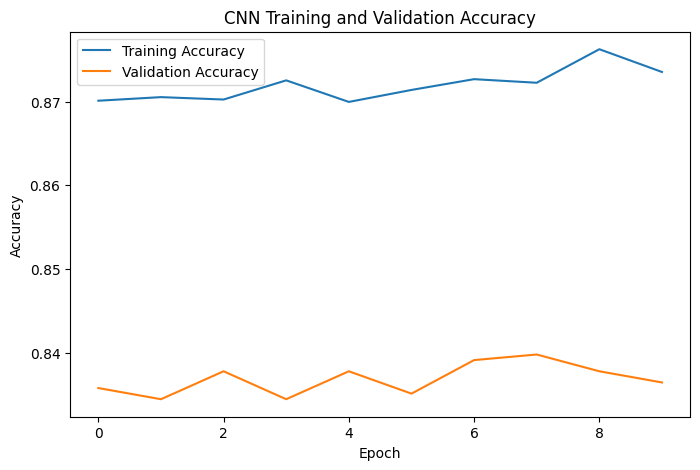

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.show()

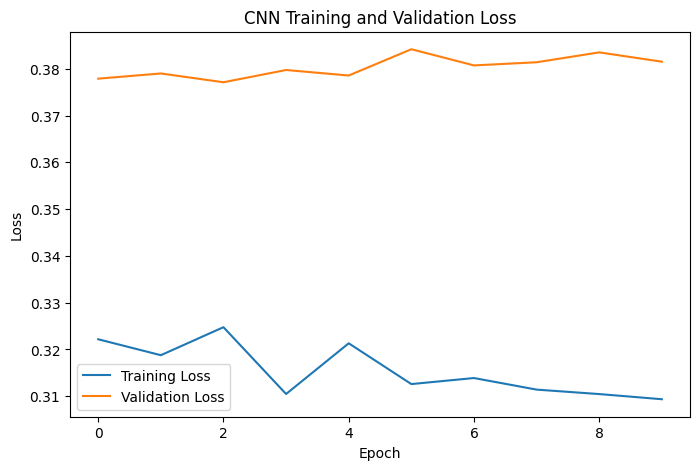

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.show()

In [99]:
test_results = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Results:")

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8439 - loss: 0.3830 - precision: 0.8482 - recall: 0.8369

Test Results:
loss: 0.3830
compile_metrics: 0.8439


In [100]:
y_prob = model.predict(X_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


In [101]:
y_pred = (y_prob >= 0.5).astype(int).ravel()

In [102]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Phishing"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.8397    0.8509    0.8452       751
    Phishing     0.8482    0.8369    0.8425       748

    accuracy                         0.8439      1499
   macro avg     0.8440    0.8439    0.8439      1499
weighted avg     0.8440    0.8439    0.8439      1499



In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[623 128]
 [115 633]]


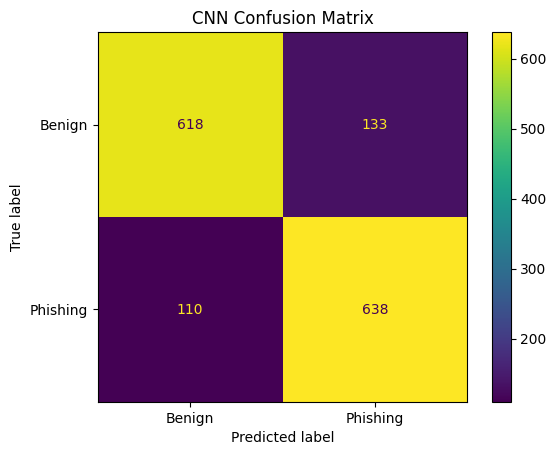

In [82]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Phishing"]
)

disp.plot()

plt.title("CNN Confusion Matrix")
plt.show()

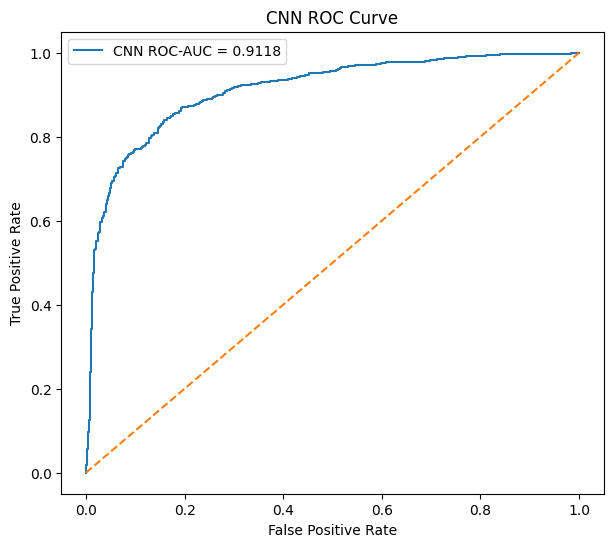

In [83]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob.ravel()
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"CNN ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve")
plt.legend()

plt.show()